In [85]:
import pandas as pd
from sklearn.model_selection import train_test_split 

In [86]:
df=pd.read_csv("C:/Users/LENOVO/Desktop/Placement_project/customer_churn_project/data/processed/customer_churn_clean.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7028,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7029,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7030,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [87]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [88]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [89]:
# Combining additional services into one column for encoding 
services_cols=[
    'OnlineSecurity',	
    'OnlineBackup',	
    'DeviceProtection',	
    'TechSupport',	
    'StreamingTV',	
    'StreamingMovies'
    ]
for col in services_cols:
    print(f'\n{col}'),
    print(df[col].value_counts())


OnlineSecurity
OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64

DeviceProtection
DeviceProtection
No                     3094
Yes                    2418
No internet service    1520
Name: count, dtype: int64

TechSupport
TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64

StreamingTV
StreamingTV
No                     2809
Yes                    2703
No internet service    1520
Name: count, dtype: int64

StreamingMovies
StreamingMovies
No                     2781
Yes                    2731
No internet service    1520
Name: count, dtype: int64


In [90]:
#here total_services column get added 
df['Total_services']=(
    df[services_cols]=='Yes'
).sum(axis=1)
df['Total_services']

0       1
1       2
2       2
3       3
4       0
       ..
7027    5
7028    4
7029    1
7030    0
7031    5
Name: Total_services, Length: 7032, dtype: int64

In [91]:
df['Total_services'].value_counts().sort_index()

Total_services
0    2213
1     966
2    1033
3    1117
4     850
5     569
6     284
Name: count, dtype: int64

In [92]:
df["Total_services"].describe()

count    7032.000000
mean        2.038111
std         1.847161
min         0.000000
25%         0.000000
50%         2.000000
75%         3.000000
max         6.000000
Name: Total_services, dtype: float64

In [93]:
df[services_cols + ["Total_services"]].head(10)

,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Total_services
0,No,Yes,No,No,No,No,1
1,Yes,No,Yes,No,No,No,2
2,Yes,Yes,No,No,No,No,2
3,Yes,No,Yes,Yes,No,No,3
4,No,No,No,No,No,No,0
5,No,No,Yes,No,Yes,Yes,3
6,No,Yes,No,No,Yes,No,2
7,Yes,No,No,No,No,No,1
8,No,No,Yes,Yes,Yes,Yes,4
9,Yes,Yes,No,No,No,No,2


In [94]:
#total_services vs Churn - having 1 services churn most
service_churn=pd.crosstab(
    df['Total_services'],
    df['Churn'],
    normalize='index'
)*100
service_churn

Churn,No,Yes
Total_services,,
0,78.535924,21.464076
1,54.244306,45.755694
2,64.181994,35.818006
3,72.605192,27.394808
4,77.647059,22.352941
5,87.521968,12.478032
6,94.718310,5.281690


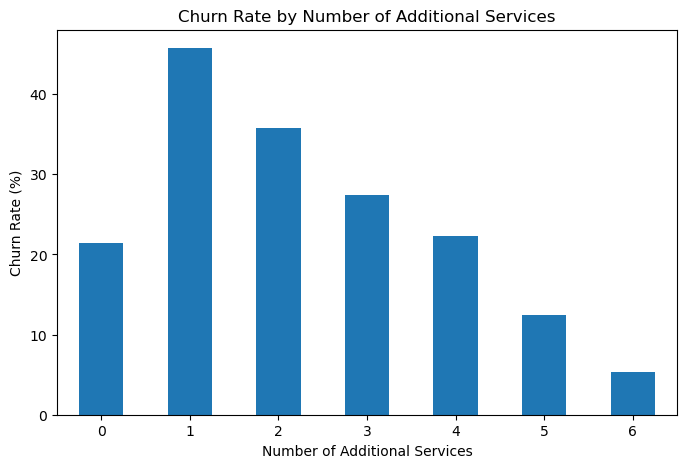

In [95]:
import matplotlib.pyplot as plt
service_churn["Yes"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Number of Additional Services")
plt.xlabel("Number of Additional Services")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [96]:
df[
    ["SeniorCitizen",
     "tenure",
     "MonthlyCharges",
     "TotalCharges",
     "Total_services"]
].corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Total_services
SeniorCitizen,1.000000,0.015683,0.219874,0.102411,0.067527
tenure,0.015683,1.000000,0.246862,0.825880,0.495318
MonthlyCharges,0.219874,0.246862,1.000000,0.651065,0.724768
TotalCharges,0.102411,0.825880,0.651065,1.000000,0.746101
Total_services,0.067527,0.495318,0.724768,0.746101,1.000000


In [97]:
#splitting the data using train test split
Y=df['Churn']

In [98]:
X=df.drop('Churn', axis=1)
X

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Total_services
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,2
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,2
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,5
7028,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,4
7029,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,1
7030,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,0


In [99]:
X=X.drop('customerID',axis=1)
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Total_services
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,2
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,5
7028,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,4
7029,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,1
7030,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,0


In [100]:
#train_test_split data
X_train,X_test,Y_train,Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y # used for We want the training and testing datasets to have approximately the same churn distribution.
)

In [101]:
print('X_train:',X_train.shape)
print('X_test:',X_test.shape)
print('Y_train:',Y_train.shape)
print('Y_test:',Y_test.shape)

X_train: (5625, 20)
X_test: (1407, 20)
Y_train: (5625,)
Y_test: (1407,)


In [102]:
print("Training Churn Distribution")
print(Y_train.value_counts(normalize=True)*100)
print("Testing Churn Distribution")
print(Y_test.value_counts(normalize=True)*100)


Training Churn Distribution
Churn
No     73.422222
Yes    26.577778
Name: proportion, dtype: float64
Testing Churn Distribution
Churn
No     73.418621
Yes    26.581379
Name: proportion, dtype: float64


In [103]:
print('Target in Xtrain:', 'Churn' in X_train.columns)
print('Target in Xtest:', 'Churn' in X_test.columns)
print(X_train.columns.tolist())

Target in Xtrain: False
Target in Xtest: False
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Total_services']


In [104]:
#differentiatiate numerical and categorical columns 
numeric_feature=[
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Total_services"
]

binary_features= [
    "SeniorCitizen"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [105]:
#standard Scaler to make values in same scale
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
numeric_transformer=StandardScaler()
categorical_transformer=OneHotEncoder(
    handle_unknown="ignore" #the pipeline safely handles the unseen category.
)
preprocessor= ColumnTransformer(
    transformers=[
    ("num",numeric_transformer,numeric_feature),
    ("bin", "passthrough", binary_features),
    ("cat",categorical_transformer,categorical_features)
    ]
)


In [106]:
X_train_processed=preprocessor.fit_transform(X_train)
X_train_processed

array([[ 1.3218163 ,  0.98155578,  1.6599004 , ...,  1.        ,
         0.        ,  0.        ],
       [-0.26741023, -0.97154551, -0.56225219, ...,  0.        ,
         1.        ,  0.        ],
       [ 1.4440645 ,  0.83706615,  1.75610395, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 0.14008375,  0.92674937,  0.47350714, ...,  1.        ,
         0.        ,  0.        ],
       [-0.9194006 ,  0.02991714, -0.721544  , ...,  0.        ,
         0.        ,  1.        ],
       [-1.28614519,  0.32221802, -0.9787973 , ...,  0.        ,
         1.        ,  0.        ]])

In [107]:
X_test_processed= preprocessor.transform(X_test) #not used fit_transform() Because the test data must use the transformations learned from training data.
X_test_processed

array([[ 1.07731992,  0.36373803,  0.98467365, ...,  1.        ,
         0.        ,  0.        ],
       [-1.0416488 ,  0.45009965, -0.78179757, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.87357292, -1.49137604, -0.53722344, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-1.20464639, -1.51296645, -0.9811925 , ...,  0.        ,
         0.        ,  1.        ],
       [ 0.18083315, -0.81210867, -0.40036741, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.71057533, -1.48971524, -0.58495165, ...,  1.        ,
         0.        ,  0.        ]])

In [108]:
feature_names = preprocessor.get_feature_names_out()

In [109]:
[col for col in feature_names if "SeniorCitizen" in col]

['bin__SeniorCitizen']

In [110]:
#verify through sample of 5 rows
sample_processed = pd.DataFrame(
    X_train_processed[:10].toarray()
    if hasattr(X_train_processed, "toarray")
    else X_train_processed[:10],
    columns=feature_names
)

sample_processed["bin__SeniorCitizen"]

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    1.0
6    0.0
7    0.0
8    0.0
9    0.0
Name: bin__SeniorCitizen, dtype: float64

In [111]:
print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("Original X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original X_train shape: (5625, 20)
Processed X_train shape: (5625, 46)
Original X_test shape: (1407, 20)
Processed X_test shape: (1407, 46)


In [112]:
print(
    "Same number of processed features:",
    X_train_processed.shape[1] == X_test_processed.shape[1]
)

Same number of processed features: True


In [113]:
feature_names=preprocessor.get_feature_names_out()
print(feature_names)
print("Number of Features:",len(feature_names))

['num__tenure' 'num__MonthlyCharges' 'num__TotalCharges'
 'num__Total_services' 'bin__SeniorCitizen' 'cat__gender_Female'
 'cat__gender_Male' 'cat__Partner_No' 'cat__Partner_Yes'
 'cat__Dependents_No' 'cat__Dependents_Yes' 'cat__PhoneService_No'
 'cat__PhoneService_Yes' 'cat__MultipleLines_No'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes'
 'cat__InternetService_DSL' 'cat__InternetService_Fiber optic'
 'cat__InternetService_No' 'cat__OnlineSecurity_No'
 'cat__OnlineSecurity_No internet service' 'cat__OnlineSecurity_Yes'
 'cat__OnlineBackup_No' 'cat__OnlineBackup_No internet service'
 'cat__OnlineBackup_Yes' 'cat__DeviceProtection_No'
 'cat__DeviceProtection_No internet service' 'cat__DeviceProtection_Yes'
 'cat__TechSupport_No' 'cat__TechSupport_No internet service'
 'cat__TechSupport_Yes' 'cat__StreamingTV_No'
 'cat__StreamingTV_No internet service' 'cat__StreamingTV_Yes'
 'cat__StreamingMovies_No' 'cat__StreamingMovies_No internet service'
 'cat__StreamingMovies_Yes'

In [114]:
#verify through sample of 5 rows
sample_processed = pd.DataFrame(
    X_train_processed[:5].toarray()
    if hasattr(X_train_processed, "toarray")
    else X_train_processed[:5],
    columns=feature_names
)

sample_processed

,num__tenure,num__MonthlyCharges,num__TotalCharges,num__Total_services,bin__SeniorCitizen,cat__gender_Female,cat__gender_Male,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,...,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_No,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
0,1.321816,0.981556,1.659900,1.053668,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1,-0.267410,-0.971546,-0.562252,-0.030848,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.444064,0.837066,1.756104,0.511410,0.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
3,-1.204646,0.641092,-0.908326,-0.030848,0.0,0.0,1.0,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.669826,-0.808787,-0.101561,-0.030848,0.0,1.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [115]:
[col for col in feature_names if 'Contract' in col]

['cat__Contract_Month-to-month',
 'cat__Contract_One year',
 'cat__Contract_Two year']

In [116]:
[col for col in feature_names if 'InternetService' in col]

['cat__InternetService_DSL',
 'cat__InternetService_Fiber optic',
 'cat__InternetService_No']

In [117]:
[col for col in feature_names if 'Churn' in col]

[]

In [118]:
print("Processed X_train:", X_train_processed.shape)
print("Processed X_test:", X_test_processed.shape)

Processed X_train: (5625, 46)
Processed X_test: (1407, 46)


In [119]:
#Encoding Churn(y_train)
Y_train_encoded=Y_train.map({
    "No":0,
    "Yes":1
})
Y_test_encoded=Y_test.map({
    "No":0,
    "Yes":1
})

In [120]:
print(Y_train_encoded.value_counts())
print(Y_test_encoded.value_counts())

Churn
0    4130
1    1495
Name: count, dtype: int64
Churn
0    1033
1     374
Name: count, dtype: int64


In [121]:
print("Missing values",Y_train_encoded.isnull().sum())
print("Missing values",Y_test_encoded.isnull().sum())

Missing values 0
Missing values 0


In [122]:
#training Logoistic Regression model
from sklearn.linear_model import LogisticRegression
logistic_model=LogisticRegression(
    max_iter=1000, #gives the optimizer more room to converge.
    random_state=42
)
logistic_model.fit(
    X_train_processed,
    Y_train_encoded
)

LogisticRegression(max_iter=1000, random_state=42)

In [123]:
#predict the model
y_pred=logistic_model.predict(X_test_processed)
y_pred

array([0, 1, 0, ..., 0, 0, 0])

In [124]:
# we needed probability for this model which is very important
y_pred_probability=logistic_model.predict_proba(X_test_processed)[:,1]
y_pred_probability #Customer Risk Scoring → Segmentation → Retention Strategy

array([0.01767787, 0.59326159, 0.00488835, ..., 0.12963756, 0.02525456,
       0.00453236])


y_pred_probability=logistic_model.predict_proba(X_test_processed)[:,1]
y_pred_probability

In [125]:
#Confusion matrix for evaluating the model performance 
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print("Accuracy",accuracy_score(Y_test_encoded,y_pred))
print("\nClassification report:",classification_report(Y_test_encoded,y_pred))
print("\nConfusion Matrix:",confusion_matrix(Y_test_encoded,y_pred))

Accuracy 0.8038379530916845

Classification report:               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Confusion Matrix: [[916 117]
 [159 215]]


In [126]:
print("\nFirst 10 Churn Probability:",y_pred_probability[:10])


First 10 Churn Probability: [0.01767787 0.59326159 0.00488835 0.20094269 0.10223124 0.47274478
 0.02657941 0.16497773 0.68168282 0.01567406]


In [127]:
#Best Model selection

In [128]:
# ============================================================
# CUSTOMER CHURN PREDICTION
# MODEL COMPARISON
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Machine Learning Models
# ------------------------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier


# ------------------------------------------------------------
# 2. Pipeline
# ------------------------------------------------------------

from sklearn.pipeline import Pipeline


# ------------------------------------------------------------
# 3. Evaluation Metrics
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)



# ------------------------------------------------------------
# 5. Define Candidate Models
# ------------------------------------------------------------

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )
}


# ------------------------------------------------------------
# 6. Store Results
# ------------------------------------------------------------

results = {}

trained_models = {}


# ------------------------------------------------------------
# 7. Train and Evaluate Every Model
# ------------------------------------------------------------

for name, model in models.items():

    print("=" * 60)
    print(f"Training: {name}")
    print("=" * 60)

    # Create pipeline
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train
    pipeline.fit(
        X_train,
        Y_train_encoded
    )

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Churn probability
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(
        Y_test_encoded,
        y_pred
    )

    precision = precision_score(
        Y_test_encoded,
        y_pred
    )

    recall = recall_score(
        Y_test_encoded,
        y_pred
    )

    f1 = f1_score(
        Y_test_encoded,
        y_pred
    )

    roc_auc = roc_auc_score(
        Y_test_encoded,
        y_proba
    )

    pr_auc = average_precision_score(
        Y_test_encoded,
        y_proba
    )

    # Store results
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }

    # Store trained pipeline
    trained_models[name] = pipeline

    # Print results
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(Y_test_encoded, y_pred))

    print("\nClassification Report:")
    print(
        classification_report(
            Y_test_encoded,
            y_pred
        )
    )


# ------------------------------------------------------------
# 8. Create Model Comparison DataFrame
# ------------------------------------------------------------

results_df = pd.DataFrame(results).T

results_df = results_df.round(4)


# ------------------------------------------------------------
# 9. Sort by F1 Score
# ------------------------------------------------------------

results_df = results_df.sort_values(
    by="F1",
    ascending=False
)


# ------------------------------------------------------------
# 10. Display Final Comparison
# ------------------------------------------------------------

print("\n")
print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

print(results_df)

#Here from evaluation we get to know that Logistic regression is best but still Xgboost is also still we go with Logistic Regression

Training: Logistic Regression
Accuracy : 0.8038
Precision: 0.6476
Recall   : 0.5749
F1 Score : 0.6091
ROC-AUC  : 0.8358
PR-AUC   : 0.6226

Confusion Matrix:
[[916 117]
 [159 215]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

Training: Decision Tree
Accuracy : 0.7896
Precision: 0.6021
Recall   : 0.6150
F1 Score : 0.6085
ROC-AUC  : 0.8296
PR-AUC   : 0.6059

Confusion Matrix:
[[881 152]
 [144 230]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1033
           1       0.60      0.61      0.61       374

    accuracy                           0.79      1407
   macro avg       0.73      0.73      0.73      1407

In [129]:
#Finding threshold value so that we can predit which csustomer has high/low risk
threshold_results=[]
thresholds=[
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60 
]
for threshold in thresholds:
    Y_pred_threshold=(
        y_proba>=threshold).astype(int)
    precision=precision_score(
        Y_test_encoded,
        Y_pred_threshold
    )
    recall=recall_score(
        Y_test_encoded,
        Y_pred_threshold
    )
    f1=f1_score(
        Y_test_encoded,
        Y_pred_threshold
    )

    threshold_results.append({
        "Threshold":threshold,
        "Precisiom":precision,
        "Recall":recall,
        "F1":f1
    })


    threshold_df=pd.DataFrame(threshold_results)
    threshold_df.round(4)

In [130]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print(best_threshold_row)

Threshold    0.400000
Precisiom    0.580796
Recall       0.663102
F1           0.619226
Name: 2, dtype: float64


In [131]:
best_threshold = best_threshold_row["Threshold"]

print("Selected threshold:", best_threshold)

Selected threshold: 0.4


In [132]:
#calculatiing risk score of every customer so used df 
final_model = trained_models["Logistic Regression"]
df["churn_probability"] = final_model.predict_proba(df)[:, 1]
df["churn_probability"]

0       0.621066
1       0.043996
2       0.286808
3       0.028193
4       0.689288
          ...   
7027    0.108806
7028    0.140441
7029    0.393264
7030    0.707448
7031    0.045395
Name: churn_probability, Length: 7032, dtype: float64

In [133]:
df['predicted_churn']=(
    df["churn_probability"]>=best_threshold
).astype(int)

In [134]:
#business risk levels
def assign_risk_level(probability):
    if probability<0.20:
        return "Low"
    elif probability<0.40:
        return "Medium"
    elif probability<0.60:
        return "High"
    else:
        return "Very High"

df['risk_level']=df['churn_probability'].apply(assign_risk_level)

In [135]:
df[
    [
        "customerID",
        "churn_probability",
        "predicted_churn",
        "risk_level"
    ]
].head(20)

,customerID,churn_probability,predicted_churn,risk_level
0,7590-VHVEG,0.621066,1,Very High
1,5575-GNVDE,0.043996,0,Low
2,3668-QPYBK,0.286808,0,Medium
3,7795-CFOCW,0.028193,0,Low
4,9237-HQITU,0.689288,1,Very High
5,9305-CDSKC,0.803479,1,Very High
6,1452-KIOVK,0.490238,1,High
7,6713-OKOMC,0.323681,0,Medium
8,7892-POOKP,0.622620,1,Very High
9,6388-TABGU,0.009335,0,Low


In [136]:
df['risk_level'].value_counts(normalize=True)*100

risk_level
Low          50.981229
Medium       18.970421
High         15.102389
Very High    14.945961
Name: proportion, dtype: float64

In [137]:
#calculate the actual churn rate inside each predicted risk group.
risk_analysis=(
    df.groupby('risk_level')
    .agg(
        customers=("customerID","count"),
        actual_churn_rate=("Churn",lambda x:(x=="Yes").mean()*100),
        avg_monthly_charges=("MonthlyCharges","mean"),
        avg_tenure=("tenure","mean")
    )
    .round(2)
)
risk_analysis

,customers,actual_churn_rate,avg_monthly_charges,avg_tenure
risk_level,,,,
High,1062,47.46,74.43,17.83
Low,3585,6.61,57.05,46.50
Medium,1334,28.49,64.52,24.70
Very High,1051,71.17,81.85,8.93


In [138]:
#Creating retention recommendations system - important
def retention_recommendation(row):
    #For very high customers
    if row['risk_level']=="Very High":
        if row['Contract']=="Month-to-month":
            return "Offer contract upgrade with retention incentive"
        elif row['MonthlyCharges']>=80:
            return "Offer personalized discount or premium plans"
        elif row['TechSupport']=="No":
            return "Offer complimentary Tech Support trail"
        else:
            return "Priority retention call"
    #For high risk customers
    if row['risk_level']=="High":
        if row['Contract']=="Month-to-month":
            return "Offer annual contract incentive"
        elif row['TechSupport']=="No":
            return "Offer Tech support bundle"
        elif row['OnlineSecurity']=="No":
            return "Offer Online Security package"
        else:
            return "Targeted retention communication"

    #For medium risk customers
    if row['risk_level']=="Medium":
        if row["tenure"]<=12:
            return "Early-life customer engagement campaign"
        if row['MonthlyCharges']>=80:
            return "High-value customer engagement"
        else:
            return "Personalized engagement campaign"

    else:
        return "Standard customer engagement"

In [139]:
df['retention_recommendation']=df.apply(
    retention_recommendation,
    axis=1
)
df['retention_recommendation']

0       Offer contract upgrade with retention incentive
1                          Standard customer engagement
2               Early-life customer engagement campaign
3                          Standard customer engagement
4       Offer contract upgrade with retention incentive
                             ...                       
7027                       Standard customer engagement
7028                       Standard customer engagement
7029            Early-life customer engagement campaign
7030    Offer contract upgrade with retention incentive
7031                       Standard customer engagement
Name: retention_recommendation, Length: 7032, dtype: object

In [140]:
df[
[  "customerID",
        "tenure",
        "MonthlyCharges",
        "Contract",
        "risk_level",
        "churn_probability",
        "retention_recommendation"
]
].head(20)

,customerID,tenure,MonthlyCharges,Contract,risk_level,churn_probability,retention_recommendation
0,7590-VHVEG,1,29.85,Month-to-month,Very High,0.621066,Offer contract upgrade with retention incentive
1,5575-GNVDE,34,56.95,One year,Low,0.043996,Standard customer engagement
2,3668-QPYBK,2,53.85,Month-to-month,Medium,0.286808,Early-life customer engagement campaign
3,7795-CFOCW,45,42.30,One year,Low,0.028193,Standard customer engagement
4,9237-HQITU,2,70.70,Month-to-month,Very High,0.689288,Offer contract upgrade with retention incentive
5,9305-CDSKC,8,99.65,Month-to-month,Very High,0.803479,Offer contract upgrade with retention incentive
6,1452-KIOVK,22,89.10,Month-to-month,High,0.490238,Offer annual contract incentive
7,6713-OKOMC,10,29.75,Month-to-month,Medium,0.323681,Early-life customer engagement campaign
8,7892-POOKP,28,104.80,Month-to-month,Very High,0.622620,Offer contract upgrade with retention incentive
9,6388-TABGU,62,56.15,One year,Low,0.009335,Standard customer engagement


In [141]:
#Identify the priority retention pool
priority_customer=df[
    df['risk_level'].isin(["High","Very High"])
].copy()
priority_customer.shape

(2113, 26)

In [142]:
#These are the customers we should contact first.
priority_customer[
    [
        "customerID",
        "churn_probability",
        "risk_level",
        "Contract",
        "tenure",
        "retention_recommendation"
        
    ]
].sort_values(
    "churn_probability",
    ascending=False
).head(20)


,customerID,churn_probability,risk_level,Contract,tenure,retention_recommendation
1971,9497-QCMMS,0.854630,Very High,Month-to-month,1,Offer contract upgrade with retention incentive
4792,9300-AGZNL,0.853560,Very High,Month-to-month,1,Offer contract upgrade with retention incentive
1405,7024-OHCCK,0.852784,Very High,Month-to-month,2,Offer contract upgrade with retention incentive
3743,4424-TKOPW,0.850638,Very High,Month-to-month,2,Offer contract upgrade with retention incentive
2203,7216-EWTRS,0.849796,Very High,Month-to-month,1,Offer contract upgrade with retention incentive
6359,2720-WGKHP,0.849733,Very High,Month-to-month,2,Offer contract upgrade with retention incentive
3374,5178-LMXOP,0.847466,Very High,Month-to-month,1,Offer contract upgrade with retention incentive
994,1374-DMZUI,0.846727,Very High,Month-to-month,4,Offer contract upgrade with retention incentive
3154,5150-ITWWB,0.846097,Very High,Month-to-month,3,Offer contract upgrade with retention incentive
301,8098-LLAZX,0.842770,Very High,Month-to-month,4,Offer contract upgrade with retention incentive


In [143]:
#Calculate potential revenue at risk 
#The monthly charges associated with customers currently classified as high/very-high churn risk.
revenue_at_risk=(
    priority_customer['MonthlyCharges'].sum()
    )
print(
    "Monthly revenue at risk:",
    round(revenue_at_risk,2)
)

Monthly revenue at risk: 165065.45


In [144]:
#Final business dataset for PowerBI dashboard
final_df=df.copy()
final_df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Total_services,churn_probability,predicted_churn,risk_level,retention_recommendation
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Yes,Electronic check,29.85,29.85,No,1,0.621066,1,Very High,Offer contract upgrade with retention incentive
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,Mailed check,56.95,1889.50,No,2,0.043996,0,Low,Standard customer engagement
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Yes,Mailed check,53.85,108.15,Yes,2,0.286808,0,Medium,Early-life customer engagement campaign
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,Bank transfer (automatic),42.30,1840.75,No,3,0.028193,0,Low,Standard customer engagement
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Yes,Electronic check,70.70,151.65,Yes,0,0.689288,1,Very High,Offer contract upgrade with retention incentive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Mailed check,84.80,1990.50,No,5,0.108806,0,Low,Standard customer engagement
7028,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,Credit card (automatic),103.20,7362.90,No,4,0.140441,0,Low,Standard customer engagement
7029,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,Yes,Electronic check,29.60,346.45,No,1,0.393264,0,Medium,Early-life customer engagement campaign
7030,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,Yes,Mailed check,74.40,306.60,Yes,0,0.707448,1,Very High,Offer contract upgrade with retention incentive


In [145]:
final_df['predicted_churn_label']=final_df['predicted_churn'].map({
    0:"No",
    1:"Yes"
})

In [146]:
final_df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Total_services', 'churn_probability', 'predicted_churn', 'risk_level',
       'retention_recommendation', 'predicted_churn_label'],
      dtype='object')

In [147]:
final_df.shape

(7032, 27)

In [148]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customerID                7032 non-null   object 
 1   gender                    7032 non-null   object 
 2   SeniorCitizen             7032 non-null   int64  
 3   Partner                   7032 non-null   object 
 4   Dependents                7032 non-null   object 
 5   tenure                    7032 non-null   int64  
 6   PhoneService              7032 non-null   object 
 7   MultipleLines             7032 non-null   object 
 8   InternetService           7032 non-null   object 
 9   OnlineSecurity            7032 non-null   object 
 10  OnlineBackup              7032 non-null   object 
 11  DeviceProtection          7032 non-null   object 
 12  TechSupport               7032 non-null   object 
 13  StreamingTV               7032 non-null   object 
 14  Streamin

In [149]:
final_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Total_services,churn_probability,predicted_churn,risk_level,retention_recommendation,predicted_churn_label
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Electronic check,29.85,29.85,No,1,0.621066,1,Very High,Offer contract upgrade with retention incentive,Yes
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Mailed check,56.95,1889.50,No,2,0.043996,0,Low,Standard customer engagement,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Mailed check,53.85,108.15,Yes,2,0.286808,0,Medium,Early-life customer engagement campaign,No
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Bank transfer (automatic),42.30,1840.75,No,3,0.028193,0,Low,Standard customer engagement,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Electronic check,70.70,151.65,Yes,0,0.689288,1,Very High,Offer contract upgrade with retention incentive,Yes


In [150]:
#important ML columns
final_df[
    [
        "customerID",
        "Churn",
        "churn_probability",
        "predicted_churn_label",
        "risk_level",
        "retention_recommendation"
    ]
].head(20)

,customerID,Churn,churn_probability,predicted_churn_label,risk_level,retention_recommendation
0,7590-VHVEG,No,0.621066,Yes,Very High,Offer contract upgrade with retention incentive
1,5575-GNVDE,No,0.043996,No,Low,Standard customer engagement
2,3668-QPYBK,Yes,0.286808,No,Medium,Early-life customer engagement campaign
3,7795-CFOCW,No,0.028193,No,Low,Standard customer engagement
4,9237-HQITU,Yes,0.689288,Yes,Very High,Offer contract upgrade with retention incentive
5,9305-CDSKC,Yes,0.803479,Yes,Very High,Offer contract upgrade with retention incentive
6,1452-KIOVK,No,0.490238,Yes,High,Offer annual contract incentive
7,6713-OKOMC,No,0.323681,No,Medium,Early-life customer engagement campaign
8,7892-POOKP,Yes,0.622620,Yes,Very High,Offer contract upgrade with retention incentive
9,6388-TABGU,No,0.009335,No,Low,Standard customer engagement


In [151]:
#Export final dataset
#final_df.to_csv("C:/Users/LENOVO/Desktop/Placement_project/customer_churn_project/data/processed/customer_churn_predictions.csv",
#index=False
#)

In [159]:
#Final prediction Function- put data and check outputs 
def predict_customer_churn(data):
    churn_probability= final_model.predict_proba(data)[:,1] #churn probability

    predicted_churn=(
        churn_probability>=best_threshold #applying business threshold
    ).astype(int)

    predicted_churn_label=pd.Series(  #Convert prediction to business label
        predicted_churn,
        index=data.index
    ).map({
        0:"No",
        1:"Yes"
    })

    def assign_risk(probability):

        if probability < 0.20:
            return "Low"

        elif probability < 0.40:
            return "Medium"

        elif probability < 0.60:
            return "High"

        else:
            return "Very High"

    risk_level=pd.Series(
        churn_probability,
        index=data.index
    ).apply(assign_risk)

    result=data.copy()   # Create result dataframe
    result['churn_probability']=churn_probability
    result['predicted_churn']=predicted_churn_label
    result['risk_level']=risk_level

    result['retention_recommendation']=result.apply(   #Retention recommendation
        retention_recommendation,
        axis=1
    )
    return result

In [162]:
test_predictions = predict_customer_churn(X_test)
test_predictions

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Total_services,churn_probability,predicted_churn,risk_level,retention_recommendation
971,Female,0,Yes,Yes,59,Yes,No,DSL,No,Yes,...,Two year,Yes,Credit card (automatic),75.95,4542.35,4,0.017678,No,Low,Standard customer engagement
618,Female,0,No,No,7,Yes,Yes,Fiber optic,No,Yes,...,Month-to-month,Yes,Bank transfer (automatic),78.55,522.95,1,0.593262,Yes,High,Offer annual contract incentive
4282,Female,0,No,No,54,Yes,No,No,No internet service,No internet service,...,Two year,No,Mailed check,20.10,1079.45,0,0.004888,No,Low,Standard customer engagement
3715,Female,0,No,No,2,Yes,No,No,No internet service,No internet service,...,Month-to-month,No,Mailed check,20.65,38.70,0,0.200943,No,Medium,Early-life customer engagement campaign
4525,Female,0,Yes,No,71,Yes,Yes,Fiber optic,No,Yes,...,Two year,Yes,Bank transfer (automatic),105.15,7555.00,4,0.102231,No,Low,Standard customer engagement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4821,Female,0,No,No,12,Yes,No,DSL,No,No,...,Month-to-month,Yes,Bank transfer (automatic),45.00,524.35,0,0.316369,No,Medium,Early-life customer engagement campaign
5168,Female,0,No,Yes,26,No,No phone service,DSL,Yes,No,...,Month-to-month,No,Mailed check,45.80,1147.00,3,0.138300,No,Low,Standard customer engagement
2745,Male,0,No,No,3,Yes,No,No,No internet service,No internet service,...,One year,Yes,Mailed check,19.45,69.25,0,0.129638,No,Low,Standard customer engagement
4424,Male,0,No,No,37,No,No phone service,DSL,Yes,Yes,...,Two year,Yes,Mailed check,40.55,1390.85,3,0.025255,No,Low,Standard customer engagement
